# Regression Analysis

---
## Part 1: What is Regression Analysis?

Regression analysis helps us understand the relationship between:
- **Features (X)**: Variables we know well (independent variables)
- **Labels (Y)**: Variables we want to predict or understand (dependent variables)

**The General Form:**
$$\hat{y}_m = f(x_m; \omega)$$

Where:
- $\hat{y}_m$ = predicted value
- $x_m$ = feature vector for sample m
- $\omega$ = parameters (what we need to learn from data)
- $f(\cdot; \omega)$ = regression function

---
## Part 2: The Rental Price Example

Predicting apartment rental prices based on floor area.

**Data:** Apartments near a university
- Feature (X): Floor area in m²
- Label (Y): Monthly rent in currency units

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset: (floor_area_m2, monthly_rent)
data = np.array([
    [78, 6600],
    [71, 6500],
    [60, 4900],
    [48, 4500],
    [52, 3800],
    [45, 4300]
])

# Separate features (X) and labels (Y)
X = data[:, 0]  # Floor area
Y = data[:, 1]  # Rent

print("Features (Floor Area):", X)
print("Labels (Monthly Rent):", Y)
print(f"\nNumber of samples (M): {len(X)}")

Features (Floor Area): [78 71 60 48 52 45]
Labels (Monthly Rent): [6600 6500 4900 4500 3800 4300]

Number of samples (M): 6


### Visualize the Data
Always start by looking at your data!

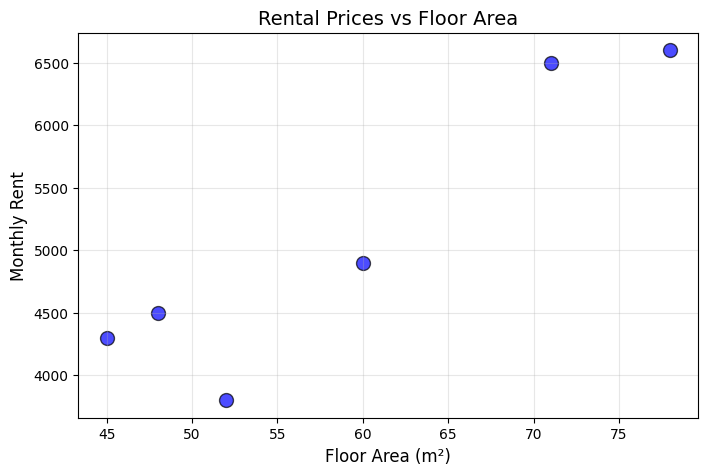

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='blue', s=100, alpha=0.7, edgecolors='black')
plt.xlabel('Floor Area (m²)', fontsize=12)
plt.ylabel('Monthly Rent', fontsize=12)
plt.title('Rental Prices vs Floor Area', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Observation: There seems to be a positive linear relationship!

---
## Part 3: The Three Elements of Regression

1. Choose a regression function
2. Define a loss function
3. Estimate parameters

### Element 1: Choose a Regression Function

For this simple problem, we'll use **Linear Regression**:
$$y = \omega_1 x + \omega_0$$

Where:
- $\omega_1$ = slope (how much rent increases per m²)
- $\omega_0$ = intercept (base rent)

**Why linear?** Our scatter plot shows the data roughly follows a line.

### Element 2: Define a Loss Function

We need to measure "how wrong" our predictions are. The most common choice for continuous data is **Mean Squared Error (MSE)**:

$$L(\omega) = \frac{1}{M} \sum_{m=1}^{M} (\hat{y}_m - y_m)^2$$

This measures the average squared difference between predictions ($\hat{y}_m$) and actual values ($y_m$).

In [21]:
def predict(X, w1, w0):
    """
    Make predictions using linear regression.
    
    Parameters:
        X: feature values (floor area)
        w1: slope parameter
        w0: intercept parameter
    
    Returns:
        y_hat: predicted values
    """
    return w1 * X + w0


def mse_loss(X, Y, w1, w0):
    """
    Calculate Mean Squared Error loss.
    
    Parameters:
        X: feature values
        Y: true labels
        w1: slope parameter
        w0: intercept parameter
    
    Returns:
        loss: MSE value
    """
    y_hat = predict(X, w1, w0)
    M = len(Y)
    loss = (1/M) * np.sum((y_hat - Y)**2)
    return loss


# Test with random parameters
test_w1, test_w0 = 50, 1000
test_loss = mse_loss(X, Y, test_w1, test_w0)
print(f"Loss with w1={test_w1}, w0={test_w0}: {test_loss:.2f}")
print("\nOur goal: find w1 and w0 that MINIMIZE this loss!")

Loss with w1=50, w0=1000: 1642500.00

Our goal: find w1 and w0 that MINIMIZE this loss!


### Element 3: Parameter Estimation

For linear regression, we can use the **closed-form solution** (analytical formula):

$$\omega_1 = \frac{\sum_{m=1}^{M}(x_m - \bar{x})(y_m - \bar{y})}{\sum_{m=1}^{M}(x_m - \bar{x})^2}$$

$$\omega_0 = \bar{y} - \omega_1 \bar{x}$$

Where $\bar{x}$ and $\bar{y}$ are the mean values of X and Y.

In [22]:
# Calculate means
x_mean = np.mean(X)
y_mean = np.mean(Y)

print(f"Mean floor area: {x_mean:.2f} m²")
print(f"Mean rent: {y_mean:.2f}")

# Calculate w1 (slope)
numerator = np.sum((X - x_mean) * (Y - y_mean))
denominator = np.sum((X - x_mean)**2)
w1_optimal = numerator / denominator

# Calculate w0 (intercept)
w0_optimal = y_mean - w1_optimal * x_mean

print(f"\n--- OPTIMAL PARAMETERS ---")
print(f"w1 (slope): {w1_optimal:.2f}")
print(f"w0 (intercept): {w0_optimal:.2f}")
print(f"\nRegression equation: y = {w1_optimal:.2f}x + {w0_optimal:.2f}")

Mean floor area: 59.00 m²
Mean rent: 5100.00

--- OPTIMAL PARAMETERS ---
w1 (slope): 82.57
w0 (intercept): 228.44

Regression equation: y = 82.57x + 228.44


**Interpretation:**
- $\omega_1 \approx 82.6$: Each additional m² increases rent by ~82.6 units
- $\omega_0 \approx 228.4$: Base rent for a hypothetical 0 m² apartment (not meaningful in practice, but mathematically necessary)

In [23]:
# Calculate final loss with optimal parameters
optimal_loss = mse_loss(X, Y, w1_optimal, w0_optimal)
print(f"Loss with optimal parameters: {optimal_loss:.2f}")
print(f"Loss with random parameters: {test_loss:.2f}")
print(f"\nImprovement: {test_loss - optimal_loss:.2f} (lower is better!)")

Loss with optimal parameters: 165840.98
Loss with random parameters: 1642500.00

Improvement: 1476659.02 (lower is better!)


---
## Part 4: Model Utilization

Now we can use our trained model for:
1. **Prediction**: Estimate rent for new apartments
2. **Interpretation**: Understand the relationship between area and rent

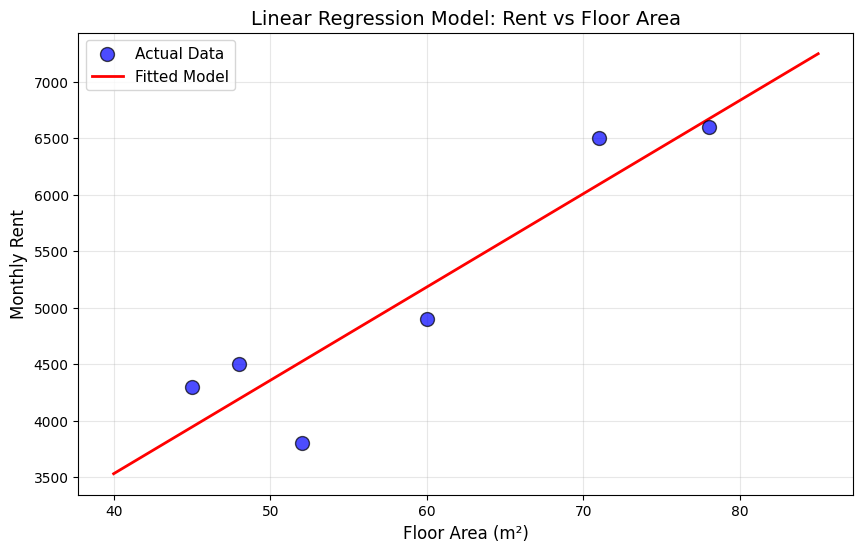

In [24]:
# Visualize the fitted model
plt.figure(figsize=(10, 6))

# Original data points
plt.scatter(X, Y, color='blue', s=100, alpha=0.7, edgecolors='black', label='Actual Data', zorder=3)

# Fitted line
x_line = np.linspace(40, 85, 100)
y_line = predict(x_line, w1_optimal, w0_optimal)
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Fitted Model', zorder=2)

plt.xlabel('Floor Area (m²)', fontsize=12)
plt.ylabel('Monthly Rent', fontsize=12)
plt.title('Linear Regression Model: Rent vs Floor Area', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### Making Predictions for New Apartments

In [25]:
# Predict rent for apartments of different sizes
new_apartments = np.array([20, 50, 100])

print("Predictions for new apartments:\n")
for area in new_apartments:
    predicted_rent = predict(area, w1_optimal, w0_optimal)
    print(f"Floor area: {area:3d} m² → Predicted rent: {predicted_rent:.2f}")

Predictions for new apartments:

Floor area:  20 m² → Predicted rent: 1879.82
Floor area:  50 m² → Predicted rent: 4356.88
Floor area: 100 m² → Predicted rent: 8485.32


---
## Part 5: Understanding Different Loss Functions

MSE is not the only choice! Let's compare it with **Mean Absolute Error (MAE)**:

$$\text{MAE}(\omega) = \frac{1}{M} \sum_{m=1}^{M} |\hat{y}_m - y_m|$$

**Key Difference:**
- MSE squares the errors → penalizes large errors more heavily
- MAE uses absolute values → treats all errors proportionally

In [26]:
def mae_loss(X, Y, w1, w0):
    """
    Calculate Mean Absolute Error loss.
    """
    y_hat = predict(X, w1, w0)
    M = len(Y)
    loss = (1/M) * np.sum(np.abs(y_hat - Y))
    return loss


# Calculate both losses
y_pred = predict(X, w1_optimal, w0_optimal)
errors = y_pred - Y

print("Prediction errors for each sample:")
for i, (true, pred, err) in enumerate(zip(Y, y_pred, errors)):
    print(f"Sample {i+1}: True={true:.0f}, Pred={pred:.0f}, Error={err:+.0f}")

mse = mse_loss(X, Y, w1_optimal, w0_optimal)
mae = mae_loss(X, Y, w1_optimal, w0_optimal)
rmse = np.sqrt(mse)

print(f"\n--- Model Performance Metrics ---")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"\nInterpretation: On average, predictions are off by ~{mae:.0f} units")

Prediction errors for each sample:
Sample 1: True=6600, Pred=6669, Error=+69
Sample 2: True=6500, Pred=6091, Error=-409
Sample 3: True=4900, Pred=5183, Error=+283
Sample 4: True=4500, Pred=4192, Error=-308
Sample 5: True=3800, Pred=4522, Error=+722
Sample 6: True=4300, Pred=3944, Error=-356

--- Model Performance Metrics ---
MSE (Mean Squared Error): 165840.98
RMSE (Root Mean Squared Error): 407.24
MAE (Mean Absolute Error): 357.80

Interpretation: On average, predictions are off by ~358 units


---
## Key Takeaways

**1. Regression Analysis Purpose:**
   - Learn relationships between features (X) and labels (Y)
   - Make predictions for new data
   - Interpret how X influences Y

**2. Three Elements (The Refrigerator Method):**
   - **Regression Function**: Choose model form (e.g., linear: $y = \omega_1 x + \omega_0$)
   - **Loss Function**: Measure prediction quality (e.g., MSE, MAE)
   - **Parameter Estimation**: Find optimal $\omega$ that minimizes loss

**3. Model Utilization:**
   - **Prediction**: Use $\hat{y} = f(x; \omega^*)$ for new samples
   - **Interpretation**: Understand parameters (slope = rate of change)
